In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle
import tensorflow as tf
import tensorflow_probability as tfp
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import joblib
import gpflow

/Users/smoon1/anaconda3/envs/ts/lib/python3.9/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
flood = pd.read_pickle('flood_df')

In [3]:
flood.iloc[0]

deployment_id                                        daily_happy_satyr
label                                                            flood
signal               {'time': [0, 567, 1009, 1639, 1765, 2080, 2395...
signal_padded        {'time': [0, 60, 120, 180, 240, 300, 360, 420,...
signal_sim           {'time': [0, 60, 120, 180, 240, 300, 867, 1309...
signal_sim_padded    {'time': [0, 60, 120, 180, 240, 300, 360, 420,...
Name: 2461972, dtype: object

In [4]:
print(flood.shape)

(841, 6)


In [5]:
def z_score_outlier_remove(signal):
    time = signal['time']
    depth = signal['depth']
    
    z_score = (depth - np.mean(depth))/np.std(depth)
    ind_to_keep = np.argwhere(z_score < 2).flatten()
    time_tidy = time[ind_to_keep]
    depth_tidy = depth[ind_to_keep]
    
    return {"time": time_tidy, "depth": depth_tidy}

#function to remove negative points
def drop_negative_depths(signal):
    time = signal["time"]
    depth = signal["depth"]
    
    ind_to_keep = np.argwhere(depth >= 0).flatten()
    
    time_tidy = time[ind_to_keep]
    depth_tidy = depth[ind_to_keep] 
    
    return {"time": time_tidy, "depth": depth_tidy}

#function to remove gradient violations
def gradient_filter(signal):
    time = signal["time"]
    depth = signal["depth"]
    
    grad = np.diff(depth,prepend=depth[0])
    ind_to_keep = np.argwhere(np.abs(grad) < 279.4).flatten()
    
    time_tidy = time[ind_to_keep]
    depth_tidy = depth[ind_to_keep] 
    
    return {"time": time_tidy, "depth": depth_tidy}

def normalize(signal):
    time = signal["time"]
    depth = signal["depth"].reshape(-1,1)
    
    # depth_max = depth.max()
    # depth_norm = depth/depth_max 
    time_max = time.max()
    time_min = time.max()

    time_norm = time/time_max 
    scaler = StandardScaler()
    # depth_mean = np.mean(depth)
    # depth_sd = np.std(depth)
    # depth_norm = (depth-depth_mean)/depth_sd
    depth_norm = scaler.fit_transform(depth).reshape(-1)
    joblib.dump(scaler, 'scaler.gz')
    return({"time":time_norm,"depth":depth_norm})


flood_outlier_rm = flood.copy(deep = True)
# flood_outlier_rm = flood_outlier_rm[flood_outlier_rm['deployment_id']=='daily_happy_satyr']
flood_outlier_rm["signal"] = flood_outlier_rm.signal.apply(lambda x: gradient_filter(drop_negative_depths(z_score_outlier_remove(x))))

flood_pp = flood_outlier_rm.copy(deep=True)
flood_pp["signal"] = flood_pp.signal.apply(lambda x: normalize(x))

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


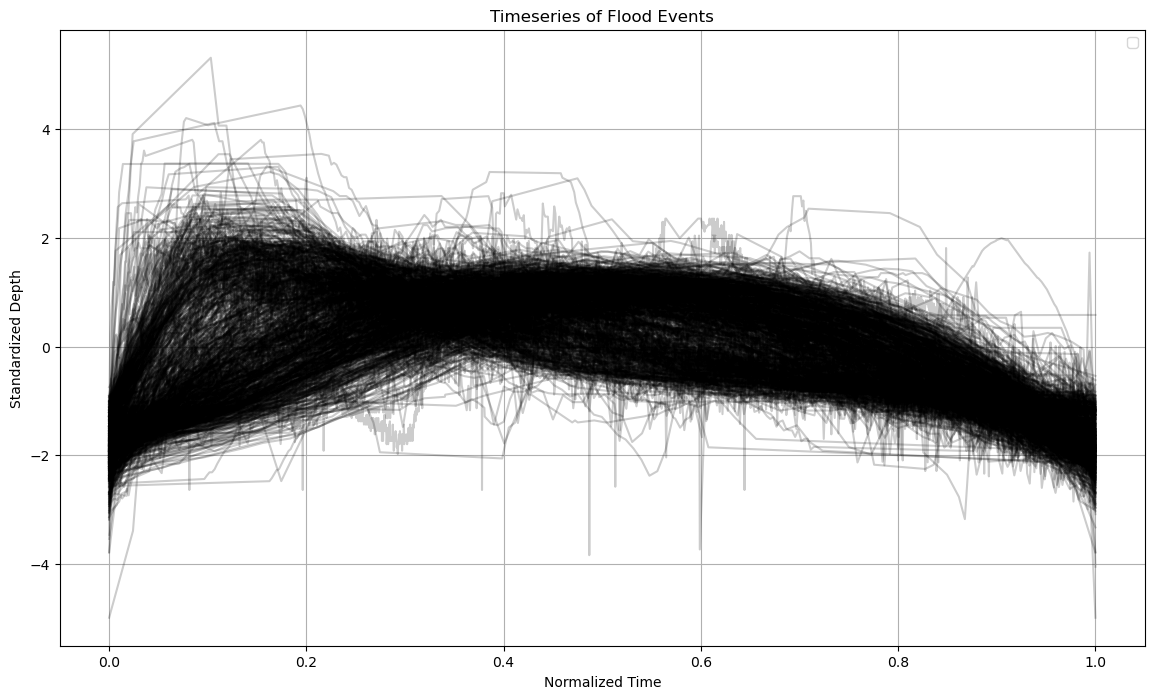

In [6]:
plt.figure(figsize=(14, 8))
for xx in flood_pp["signal"]:
    plt.plot(xx['time'].ravel(), xx['depth'].ravel(),"k-",alpha=0.2)

# Add labels, legend, and grid
plt.xlabel('Normalized Time')
plt.ylabel('Standardized Depth')
plt.title('Timeseries of Flood Events')
plt.legend()
plt.grid(True)

# Show the plot
plt.show()

In [7]:
# Prepare data
X_list = []  # List of normalized time inputs
Y_list = []  # List of standardized flood values

for timeseries in flood_pp["signal"]:
    X = timeseries['time']
    Y = timeseries['depth']
    X_list.append(X)
    Y_list.append(Y)

X = np.concatenate(X_list).reshape(-1,1)
Y = np.concatenate(Y_list).reshape(-1,1)

In [8]:
def plot_model(model: gpflow.models.GPModel) -> None:
    X, Y = model.data
    opt = gpflow.optimizers.Scipy()
    opt.minimize(model.training_loss, model.trainable_variables)
    gpflow.utilities.print_summary(model, "notebook")

    Xplot = np.linspace(0.0, 1.0, 200)[:, None]

    y_mean, y_var = model.predict_y(Xplot, full_cov=False)
    y_lower = y_mean - 1.96 * np.sqrt(y_var)
    y_upper = y_mean + 1.96 * np.sqrt(y_var)
    
    plt.figure(figsize=(14, 8))
    _, ax = plt.subplots(nrows=1, ncols=1, figsize=(14, 6))
    ax.plot(X, Y, "kx", mew=2, alpha=0.8, zorder=1)
    (mean_line,) = ax.plot(Xplot, y_mean, "-", zorder=5, label='mean_line')
    color = mean_line.get_color()
    ax.plot(Xplot, y_lower, lw=0.1, color=color,zorder=4)
    ax.plot(Xplot, y_upper, lw=0.1, color=color,zorder=3)
    ax.fill_between(
        Xplot[:, 0], y_lower[:, 0], y_upper[:, 0], color=color, alpha=0.3, label='95% CI', zorder=2
    )
    
    # Also plot the inducing variables if possible:
    iv = getattr(model, "inducing_variable", None)
    if iv is not None:
        ax.scatter(iv.Z, np.zeros_like(iv.Z), marker="^")
    plt.xlabel('Normalized Time')
    plt.ylabel('Standardized Depth')
    plt.title('Timeseries of Flood Events')
    plt.legend()


2024-12-10 10:44:17.407620: W tensorflow/core/platform/profile_utils/cpu_utils.cc:128] Failed to get CPU frequency: 0 Hz


name,class,transform,prior,trainable,shape,dtype,value
SGPR.kernel.kernels[0].variance,Parameter,Softplus,,True,(),float64,256652.42452
SGPR.kernel.kernels[0].lengthscales,Parameter,Softplus,,True,(),float64,126.84196
SGPR.kernel.kernels[1].variance,Parameter,Softplus,,True,(),float64,0.0
SGPR.likelihood.variance,Parameter,Softplus + Shift,,True,(),float64,0.487329958658827
SGPR.inducing_variable.Z,Parameter,Identity,,True,"(4, 1)",float64,[[-0.00339576...


<Figure size 1400x800 with 0 Axes>

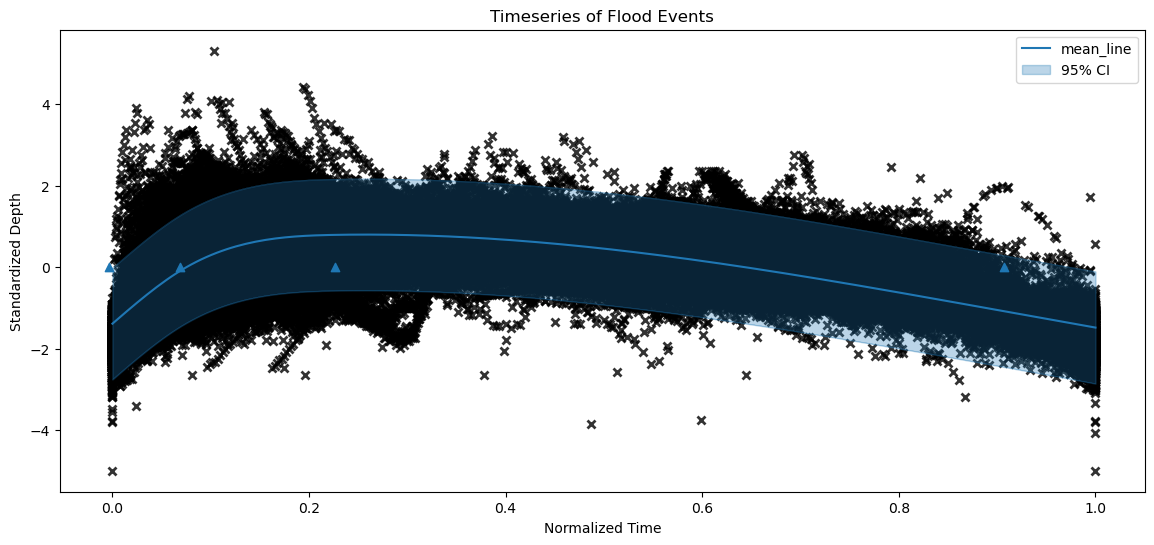

In [9]:
inducing_points = np.array([[0.125], [0.375], [0.625], [0.875]])
model = gpflow.models.SGPR(
    (X, Y),
    kernel= gpflow.kernels.Matern32()+ gpflow.kernels.White(variance=1.0),
    inducing_variable=inducing_points,
)

plot_model(model)

In [10]:
hasattr(model, "compiled_predict_f")

False

In [11]:
model.compiled_predict_f = tf.function(
    lambda Xnew: model.predict_f(Xnew, full_cov=False),
    input_signature=[tf.TensorSpec(shape=[None, 1], dtype=tf.float64)],
)
model.compiled_predict_y = tf.function(
    lambda Xnew: model.predict_y(Xnew, full_cov=False),
    input_signature=[tf.TensorSpec(shape=[None, 1], dtype=tf.float64)],
)

save_dir = "saved_model_0"
tf.saved_model.save(model, save_dir)

Instructions for updating:
`min_event_ndims` is now static for all bijectors; this property is no longer needed.
INFO:tensorflow:Assets written to: saved_model_0/assets


In [12]:
flood_gp = tf.saved_model.load(save_dir)

In [13]:
def evaluate_result(signal):
    #extract timestamps and measured data as vectors from the measured signal df
    X = np.array(signal['time']).reshape(-1,1)
    Y = np.array(signal['depth']).reshape(-1,1)

    y_mean, y_var = model.compiled_predict_y(X)
    y_lower = y_mean - 1.98 * np.sqrt(y_var)
    y_upper = y_mean + 1.98 * np.sqrt(y_var)

    non_flood_events = np.logical_or(Y < y_lower, Y > y_upper)
    num_non_flood_detected = np.sum(non_flood_events)
    non_flood_detected = num_non_flood_detected / len(non_flood_events)

    return non_flood_detected
    

In [14]:
results =[]
for timeseries in flood_pp["signal_padded"]:
    result = evaluate_result(timeseries)
    results.append(result)

results = np.array(results)
mean = np.mean(results)
print(f'filtering result: {mean}')

filtering result: 0.012188190360563917
